# Resolução de Otimização em Julia

Este notebook utiliza a linguagem **Julia** com a biblioteca **JuMP** e os solvers **HiGHS** (Linear/Inteiro) e **Ipopt** (Não-Linear).

In [ ]:
using Plots
using JuMP
using HiGHS
using Ipopt

## Exercício 1: Gráficos de Funções Trigonométricas

Plotar $sin(x)$ no intervalo $[-\pi/4, 3\pi/4]$.

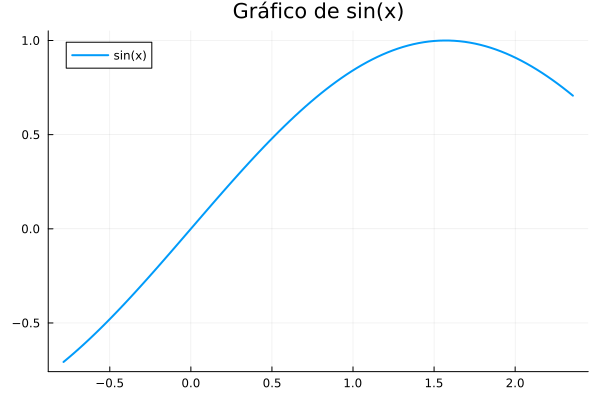

In [5]:
x = range(-pi/4, 3*pi/4, length=100)
y = sin.(x)
plot(x, y, title="Gráfico de sin(x)", label="sin(x)", lw=2)

Plotar $x \cdot sin(x)$ no intervalo $[-10\pi, 10\pi]$.

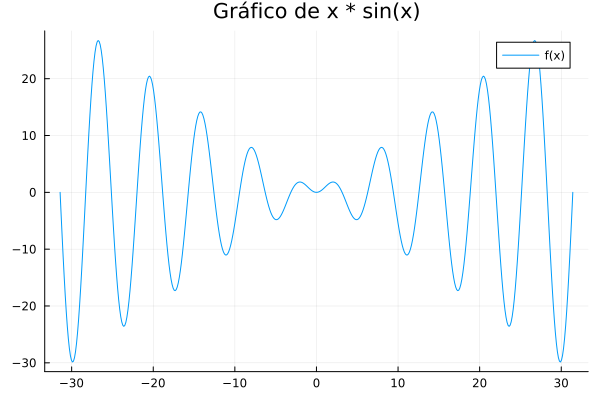

In [6]:
x2 = range(-10*pi, 10*pi, length=500)
y2 = x2 .* sin.(x2)
plot(x2, y2, title="Gráfico de x * sin(x)", label="f(x)", lw=1)

## Exercício 2: Problema do Cilindro (Não-Linear)

Minimizar o custo de um cilindro com volume fixo $N=10$.

In [9]:
model_cilindro = Model(Ipopt.Optimizer)
set_silent(model_cilindro)

N = 10; c1 = 2; c2 = 0.5

@variable(model_cilindro, r >= 0.001, start = 1.0)
@variable(model_cilindro, h >= 0.001, start = 1.0)

# Fórmulas limpas sem erros de texto
@NLobjective(model_cilindro, Min, c1 * (2 * pi * r^2) + c2 * (2 * pi * r * h))
@NLconstraint(model_cilindro, pi * r^2 * h == N)

optimize!(model_cilindro)

println("Raio ideal (r): ", value(r))
println("Altura ideal (h): ", value(h))
println("Custo total mínimo: ", objective_value(model_cilindro))



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Raio ideal (r): 0.7355068357939302
Altura ideal (h): 5.884054687434677
Custo total mínimo: 20.3941000533162


## Exercício 3: Problema do Toldo (Não-Linear)

Maximizar a área de sombra $x \cdot y$ com restrição elíptica.

In [10]:
model_toldo = Model(Ipopt.Optimizer)
set_silent(model_toldo)

h_val = 2; w_val = 3

@variable(model_toldo, x >= 0, start = 1.0)
@variable(model_toldo, y >= 0, start = 1.0)

@NLobjective(model_toldo, Max, x * y)
@NLconstraint(model_toldo, (x/w_val)^2 + (y/h_val)^2 <= 1)

optimize!(model_toldo)

println("X ideal: ", value(x))
println("Y ideal: ", value(y))
println("Área Máxima de Sombra: ", objective_value(model_toldo))


X ideal: 2.1213203532799714
Y ideal: 1.4142135688533182
Área Máxima de Sombra: 3.00000002749325


## Exercício 4: Alocação de Designers (Linear)

Maximizar a pontuação total de competência.

In [11]:
model_alocacao = Model(HiGHS.Optimizer)
set_silent(model_alocacao)

designers = 1:3; projetos = 1:4
scores = [90 80 10 50; 60 70 50 65; 70 40 80 85]
demandas = [70, 50, 85, 35]
h_max = 80

@variable(model_alocacao, h[designers, projetos] >= 0)
@objective(model_alocacao, Max, sum(h[i,j] * scores[i,j] for i in designers, j in projetos))

for i in designers
    @constraint(model_alocacao, sum(h[i,j] for j in projetos) <= h_max)
end
for j in projetos
    @constraint(model_alocacao, sum(h[i,j] for i in designers) >= demandas[j])
end

optimize!(model_alocacao)

println("Pontuação Total Máxima: ", objective_value(model_alocacao))


Pontuação Total Máxima: 18825.0


## Exercício 5: Problema da Dieta (Linear)

Minimizar o custo atendendo aos requisitos nutricionais.

In [12]:
model_dieta = Model(HiGHS.Optimizer)
set_silent(model_dieta)

@variable(model_dieta, dy[1:4] >= 0)
@objective(model_dieta, Min, 1*dy[1] + 0.5*dy[2] + 2*dy[3] + 0.3*dy[4])

@constraint(model_dieta, 100*dy[1] + 200*dy[2] + 150*dy[3] + 70*dy[4] >= 500)
@constraint(model_dieta, 0.5*dy[1] + 4*dy[2] + 8*dy[3] + 6*dy[4] >= 50)
@constraint(model_dieta, 2*dy[1] + 10*dy[3] >= 100)

optimize!(model_dieta)

println("Custo Mínimo: ", objective_value(model_dieta))


Custo Mínimo: 20.0


## Exercício 6: Problema da Mochila (Inteiro/Binário)

Maximizar o valor sem exceder o peso.

In [13]:
model_mochila = Model(HiGHS.Optimizer)
set_silent(model_mochila)

@variable(model_mochila, mx[1:3], Bin)
@objective(model_mochila, Max, 120*mx[1] + 80*mx[2] + 60*mx[3])

@constraint(model_mochila, 2*mx[1] + 1*mx[2] + 1*mx[3] <= 3.5)

optimize!(model_mochila)

println("Valor Total: ", objective_value(model_mochila))


Valor Total: 200.0
